métriques : sur 50 runs
- mean and std reward
- longueur moyenne de l'épisode
- distance parcourue
- % épisodes terminés sans collision
- distribution des actions

In [20]:
import gymnasium as gym
from copy import deepcopy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import highway_env

from stable_baselines3 import DQN

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Config

In [3]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

EVAL_SEEDS = list(range(50))  # for reproducible 

ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

env = make_env(SHARED_CORE_CONFIG)
obs, _ = env.reset()
print("Observation shape :", obs.shape)
print("Action space      :", env.action_space)
print("Flattened obs size:", obs.flatten().shape[0])


Observation shape : (10, 5)
Action space      : Discrete(5)
Flattened obs size: 50


## Agents

### Random agent

In [4]:
def get_action_random(obs):
    return env.action_space.sample()

### DQN 1 layer

In [9]:
class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [10]:
CHECKPOINT_PATH = "Checkpoints\dqn_1_layer.pt"

env_tmp = make_env(SHARED_CORE_CONFIG)
obs, _ = env_tmp.reset()
OBS_SIZE  = obs.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n

custom_dqn = QNet(OBS_SIZE, N_ACTIONS).to(device)
custom_dqn.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
custom_dqn.eval()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\arfib\AppData\Local\Temp\ipykernel_30324\3298983749.py:1: SyntaxWarning: invalid escape sequence '\d'
  CHECKPOINT_PATH = "Checkpoints\dqn_1_layer.pt"


QNet(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [12]:
def get_action_1_layer(obs):
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = custom_dqn(state_t)
    return q_values.argmax(dim=1).item()

### DQN 2 layers

In [14]:
class QNet2Layers(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [15]:
CHECKPOINT_PATH = "Checkpoints\dqn_2_layers.pt"

env_tmp = make_env(SHARED_CORE_CONFIG)
obs, _ = env_tmp.reset()
OBS_SIZE  = obs.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n

custom_dqn_2_layers = QNet2Layers(OBS_SIZE, N_ACTIONS).to(device)
custom_dqn_2_layers.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
custom_dqn_2_layers.eval()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\arfib\AppData\Local\Temp\ipykernel_30324\3756331833.py:1: SyntaxWarning: invalid escape sequence '\d'
  CHECKPOINT_PATH = "Checkpoints\dqn_2_layers.pt"


QNet2Layers(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [16]:
def get_action_2_layers(obs):
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = custom_dqn_2_layers(state_t)
    return q_values.argmax(dim=1).item()

### Double DQN

In [21]:
class Net(nn.Module):
    def __init__(self, state_dim, action_dim):
        """
        Initialize the network

        : param state_dim: int, size of state space
        : param action_dim: int, size of action space
        """
        super(Net, self).__init__()

        hidden_nodes1 = 512
        hidden_nodes2 = 256
        self.fc1 = nn.Linear(state_dim, hidden_nodes1)
        self.fc2 = nn.Linear(hidden_nodes1, hidden_nodes2)
        self.fc3 = nn.Linear(hidden_nodes2, action_dim)

    def forward(self, state):
        """
        Define the forward pass of the actor

        : param state: ndarray, the state of the environment
        """
        x = state
        # print(x.shape)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        out = self.fc3(x)
        return out

In [23]:
load_path = "Double DQN/0327_16_17/double_dqn.pkl"

loaded_net = Net(state_dim=50, action_dim=5).to(device)
loaded_net.load_state_dict(torch.load(load_path, map_location=device))
loaded_net.eval()

Net(
  (fc1): Linear(in_features=50, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=5, bias=True)
)

In [24]:
def get_action_double_DQN(obs):
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = loaded_net(state_t)
    return q_values.argmax(dim=1).item()

### DQN stable baselines

In [25]:
sb_dqn = DQN.load("dqn_stable_baseline_with_config_prof")

In [26]:
def get_action_sb(obs):
    action, _states = sb_dqn.predict(obs, deterministic=True)
    return action

## Métriques

In [27]:
def eval_agent(get_action, CONFIG, EVAL_SEEDS):
    """
    Monte Carlo evaluation using fixed seeds.
    """
    n_sim = len(EVAL_SEEDS)

    env = make_env(CONFIG)
    env_copy = deepcopy(env)

    episode_rewards = np.zeros(n_sim)
    episode_lengths = np.zeros(n_sim)
    episode_distances = np.zeros(n_sim)
    episode_collisions = np.zeros(n_sim, dtype=bool)
    episode_actions = []

    for i, seed in enumerate(EVAL_SEEDS):
        print(f"Simulating episode {i} with seed {seed}")

        state, _ = env_copy.reset(seed=seed)
        reward_sum = 0
        length = 0
        distance = 0
        actions = []
        done = False
        while not done: 
            action = get_action(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env_copy.step(action)
            reward_sum += reward
            length+=1
            dt = 1 / env_copy.unwrapped.config["simulation_frequency"]
            speed = env_copy.unwrapped.vehicle.speed
            distance += speed * dt
            done = terminated or truncated
        if terminated:
            episode_collisions[i] = True
        episode_rewards[i] = reward_sum
        episode_lengths[i] = length
        episode_distances[i] = distance
        episode_actions.append(actions)
    return episode_rewards, episode_lengths, episode_distances, episode_collisions, episode_actions

In [28]:
EVAL_SEEDS = list(range(50))
eval_double_dqn=eval_agent(get_action_double_DQN, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_random = eval_agent(get_action_random, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_custom_1_layer = eval_agent(get_action_1_layer, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_custom_2_layers = eval_agent(get_action_2_layers, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_sb = eval_agent(get_action_sb, SHARED_CORE_CONFIG, EVAL_SEEDS)

Simulating episode 0 with seed 0
Simulating episode 1 with seed 1
Simulating episode 2 with seed 2
Simulating episode 3 with seed 3
Simulating episode 4 with seed 4
Simulating episode 5 with seed 5
Simulating episode 6 with seed 6
Simulating episode 7 with seed 7
Simulating episode 8 with seed 8
Simulating episode 9 with seed 9
Simulating episode 10 with seed 10
Simulating episode 11 with seed 11
Simulating episode 12 with seed 12
Simulating episode 13 with seed 13
Simulating episode 14 with seed 14
Simulating episode 15 with seed 15
Simulating episode 16 with seed 16
Simulating episode 17 with seed 17
Simulating episode 18 with seed 18
Simulating episode 19 with seed 19
Simulating episode 20 with seed 20
Simulating episode 21 with seed 21
Simulating episode 22 with seed 22
Simulating episode 23 with seed 23
Simulating episode 24 with seed 24
Simulating episode 25 with seed 25
Simulating episode 26 with seed 26
Simulating episode 27 with seed 27
Simulating episode 28 with seed 28
Simul

In [29]:
def print_eval_metrics(eval_output, label="Custom DQN"):
    """
    Print performance metrics from eval_agent output.
    """
    rewards, lengths, distances, collisions, actions = eval_output

    # Reward
    reward_mean = rewards.mean()
    reward_std = rewards.std()

    # Longueur épisode
    length_mean = lengths.mean()
    length_std = lengths.std()

    # Distance
    distance_mean = distances.mean()
    distance_std = distances.std()

    # Sécurité
    success_rate = 100 * (~collisions).mean()  # % sans collision
    collision_rate = 100 * collisions.mean()

    print(f"Evaluation Results for network {label}")
    print(f"Reward: mean = {reward_mean:.3f}, std = {reward_std:.3f}")
    print(f"Length: mean = {length_mean:.2f}, std = {length_std:.2f}")
    print(f"Distance: mean = {distance_mean:.2f}, std = {distance_std:.2f}")
    print(f"No collision: {success_rate:.1f}%")
    print(f"Collision: {collision_rate:.1f}%")

In [30]:
print_eval_metrics(eval_random, "Random Policy")
print("\n")
print_eval_metrics(eval_custom_1_layer, "Custom DQN 1 layer")
print("\n")
print_eval_metrics(eval_custom_2_layers, "Custom DQN 2 layers")
print("\n")
print_eval_metrics(eval_sb, "Stable baselines")
print("\n")
print_eval_metrics(eval_double_dqn, "Double DQN")

Evaluation Results for network Random Policy
Reward: mean = 9.263, std = 7.331
Length: mean = 12.36, std = 9.30
Distance: mean = 19.64, std = 14.51
No collision: 14.0%
Collision: 86.0%


Evaluation Results for network Custom DQN 1 layer
Reward: mean = 20.506, std = 0.165
Length: mean = 30.00, std = 0.00
Distance: mean = 40.22, std = 0.50
No collision: 100.0%
Collision: 0.0%


Evaluation Results for network Custom DQN 2 layers
Reward: mean = 19.503, std = 4.056
Length: mean = 27.50, std = 6.14
Distance: mean = 38.94, std = 7.57
No collision: 82.0%
Collision: 18.0%


Evaluation Results for network Stable baselines
Reward: mean = 16.391, std = 8.987
Length: mean = 17.80, std = 9.12
Distance: mean = 33.79, std = 17.71
No collision: 24.0%
Collision: 76.0%


Evaluation Results for network Double DQN
Reward: mean = 19.286, std = 4.903
Length: mean = 27.48, std = 6.85
Distance: mean = 38.42, std = 9.32
No collision: 86.0%
Collision: 14.0%


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_action_distribution(eval_output, n_actions, action_labels=None, title="Action distribution"):
    episode_rewards, episode_lengths, episode_distances, episode_collisions, episode_actions = eval_output

    all_actions = np.concatenate(episode_actions)
    counts = np.bincount(all_actions, minlength=n_actions)
    if action_labels is None:
        labels = [str(i) for i in range(n_actions)]
    else:
        labels = [action_labels.get(i, str(i)) for i in range(n_actions)]

    x = np.arange(n_actions)

    plt.figure(figsize=(6, 4))
    plt.bar(x, counts, alpha=0.8)
    plt.xticks(x, labels, rotation=15)
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

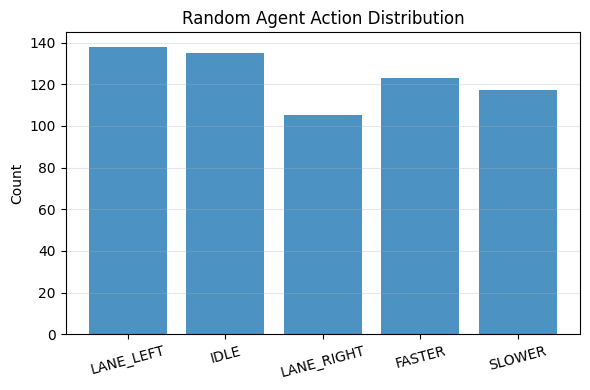

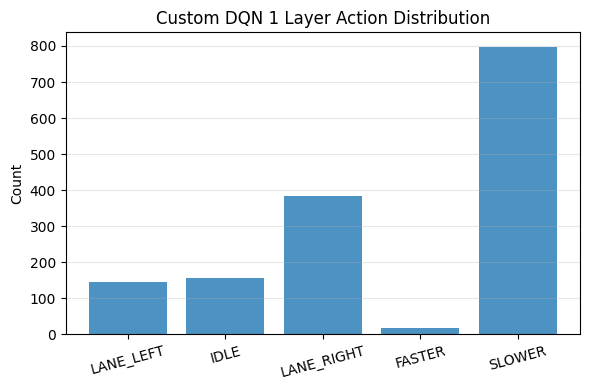

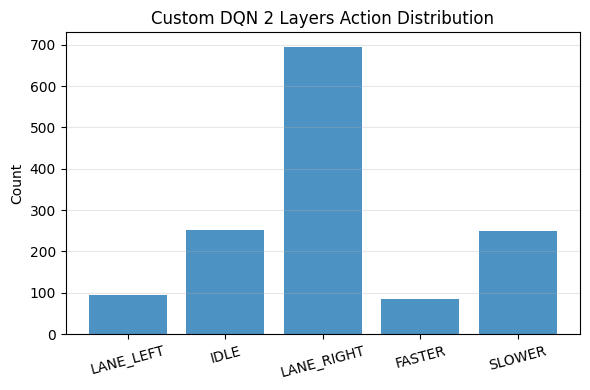

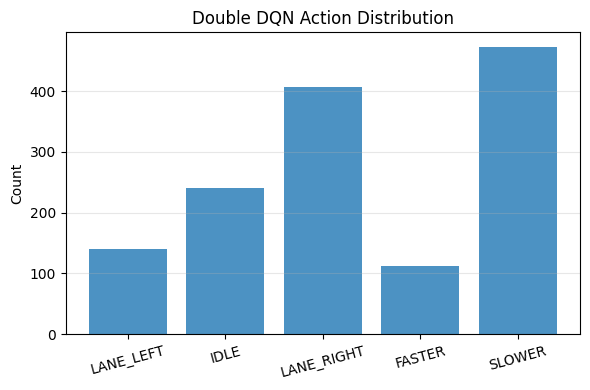

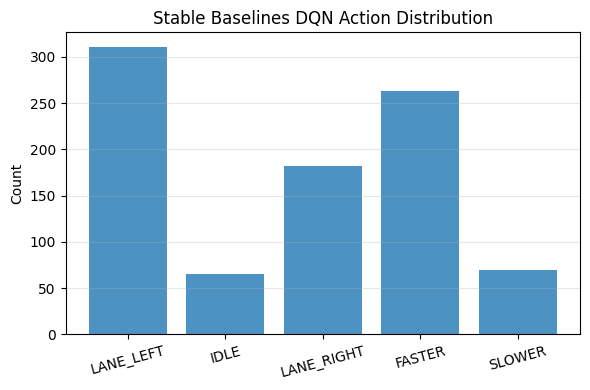

In [32]:
plot_action_distribution(eval_random, N_ACTIONS, action_labels=ACTION_LABELS, title="Random Agent Action Distribution")
plot_action_distribution(eval_custom_1_layer, N_ACTIONS, action_labels=ACTION_LABELS, title="Custom DQN 1 Layer Action Distribution")
plot_action_distribution(eval_custom_2_layers, N_ACTIONS, action_labels=ACTION_LABELS, title="Custom DQN 2 Layers Action Distribution")
plot_action_distribution(eval_double_dqn, N_ACTIONS, action_labels=ACTION_LABELS, title="Double DQN Action Distribution")
plot_action_distribution(eval_sb, N_ACTIONS, action_labels=ACTION_LABELS, title="Stable Baselines DQN Action Distribution")

## Analyse des comportements

Sur un run :
- évolution du reward
- distribution des actions
- vitesse 


In [33]:
import numpy as np
import matplotlib.pyplot as plt

def compare_agents(get_actions, agent_names, CONFIG, seed, n_actions, action_labels=None):

    episodes_data = []

    for get_action in get_actions:
        env = make_env(CONFIG)
        state, _ = env.reset(seed=seed)

        rewards = []
        actions = []
        speeds = []

        done = False
        while not done:
            action = get_action(state)
            actions.append(action)

            state, reward, terminated, truncated, _ = env.step(action)

            rewards.append(reward)
            speeds.append(env.unwrapped.vehicle.speed)

            done = terminated or truncated

        episodes_data.append({
            "rewards": np.array(rewards),
            "actions": np.array(actions),
            "speeds": np.array(speeds),
        })

    n_agents = len(episodes_data)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    for i, data in enumerate(episodes_data):
        ax.plot(np.cumsum(data["rewards"]), lw=2, color=colors[i], label=agent_names[i])

    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Reward")
    ax.set_title("Cumulative reward")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    for i, data in enumerate(episodes_data):
        ax.plot(data["speeds"], lw=2, color=colors[i], label=agent_names[i])

    ax.set_xlabel("Step")
    ax.set_ylabel("Speed")
    ax.set_title("Speed over time")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[2]
    x = np.arange(n_actions)
    width = 0.8 / n_agents

    if action_labels is None:
        labels = [str(i) for i in range(n_actions)]
    else:
        labels = [action_labels.get(i, str(i)) for i in range(n_actions)]

    for i, data in enumerate(episodes_data):
        counts = np.bincount(data["actions"], minlength=n_actions)

        ax.bar(x+i*width-(n_agents-1)*width/2, counts, width, label=agent_names[i], alpha=0.8, color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Count")
    ax.set_title("Action distribution")
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

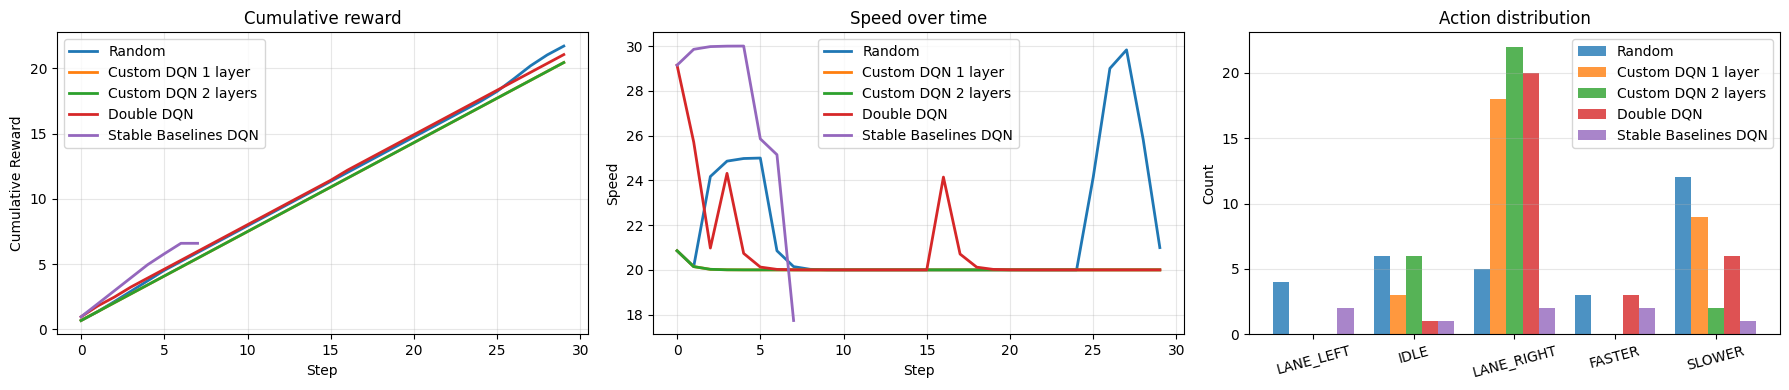

In [34]:
compare_agents(
    get_actions=[get_action_random, get_action_1_layer, get_action_2_layers, get_action_double_DQN, get_action_sb],
    agent_names=["Random", "Custom DQN 1 layer", "Custom DQN 2 layers", "Double DQN", "Stable Baselines DQN"],
    CONFIG=SHARED_CORE_CONFIG,
    seed=0,
    n_actions=N_ACTIONS,
    action_labels=ACTION_LABELS
)